# Saccade‑aligned LFP average pipeline

**Environment:** Use the `eye_repo` conda environment.

This pipeline loads the exported `all_saccade_collection`, infers the required (animal, block) set, instantiates only those BlockSync blocks, filters to **synchronized (binocular) saccades only**, and computes **averaged LFP traces** aligned to saccade onset (t = 0), with **one average trace per animal** (no mixing across animals).

**Prerequisites:**
- Run `saccade_collection_pipeline.ipynb` and export `all_saccade_collection` to the configured `export_dir`.
- Electrophysiology (OE) data available for each block (`oe_rec` on BlockSync).

In [16]:
# =============================================================================
# IMPORTS
# =============================================================================
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from eye_tracking_system_tools.preprocessing import BlockSync
from eye_tracking_system_tools.preprocessing import utility_functions as uf

## Config

- `experiment_path`: parent of animal folders (same as saccade pipeline).
- `collection_path`: path to exported `all_saccade_collection.csv` (or use `export_dir` / `export_filename` from saccade pipeline).
- `lfp_channels`: list of OE channel numbers for LFP (e.g. `[1]`).
- `window_ms`: total window around saccade onset (ms). We use **± half_window**, so 100 ms → -50 to +50 ms.

In [17]:
experiment_path = Path(r"D:\sample_data_for_eye_repo")
export_dir = experiment_path / "analysis" / "saccade_collections"
export_filename = "all_saccade_collection.csv"
collection_path = export_dir / export_filename

lfp_channels = [1]   # OE channel numbers for LFP
window_ms = 200.0    # total window around onset (ms); we use ± window_ms/2
half_window_ms = window_ms / 2

## Load `all_saccade_collection` and infer required (animal, block) set

Load the exported collection, then derive unique `(animal, block)` pairs to instantiate only those BlockSync blocks.

In [18]:
all_saccade_collection = pd.read_csv(collection_path)
required = ["animal", "block", "Main", "Sub", "saccade_on_ms"]
missing = [c for c in required if c not in all_saccade_collection.columns]
if missing:
    raise ValueError(f"all_saccade_collection missing columns: {missing}")
print(f"Loaded {len(all_saccade_collection):,} rows from {collection_path.name}")

ab = all_saccade_collection[["animal", "block"]].drop_duplicates()
animals = ab["animal"].dropna().unique().astype(str).tolist()
block_lists = [
    [int(b) for b in ab.loc[ab["animal"] == a, "block"].dropna().unique().astype(str).tolist()]
    for a in animals
]
print(f"Inferred animals: {animals}; block_lists: {block_lists}")

Loaded 3,557 rows from all_saccade_collection.csv
Inferred animals: ['PV_126', 'PV_106']; block_lists: [[6], [15]]


## Build `block_collection` and `block_dict` for inferred (animal, block) only

Reuse the same helpers as the saccade pipeline. We only need BlockSync instances with `oe_rec`; no need to load `final_sync_df` or eye data for LFP extraction.

In [19]:
def create_block_collections(animals, block_lists, experiment_path, bad_blocks=None):
    """Build block_collection and block_dict from animals and block lists."""
    if bad_blocks is None:
        bad_blocks = []
    block_collection = []
    block_dict = {}
    for animal, blocks in zip(animals, block_lists):
        current = uf.block_generator(
            block_numbers=blocks,
            experiment_path=experiment_path,
            animal=animal,
            bad_blocks=bad_blocks,

        )
        block_collection.extend(current)
        for b in current:
            block_dict[f"{animal}_block_{b.block_num}"] = b
    return block_collection, block_dict

block_collection, block_dict = create_block_collections(
    animals=animals,
    block_lists=block_lists,
    experiment_path=experiment_path,
    bad_blocks=[],

)
print(f"Blocks: {list(block_dict.keys())}")

instantiated block number 006 at Path: D:\sample_data_for_eye_repo\PV_126\2024_07_18\block_006, new OE version
Found the sample rate for block 006 in the xml file, it is 20000 Hz

Extracting meta data from: D:\sample_data_for_eye_repo\PV_126\2024_07_18\block_006\oe_files\PV126_Trial15_hunter7_2024-07-18_12-25-35\Record Node 102...
xml data matches file data.

Extracting time stamp information...

Error!!! Some blocks are missing in recording!!!

Checking integrity of all records in ch1...

Metadata extraction complete.
created the .oe_rec attribute as an open ephys recording obj with get_data functionality (standalone mode)
retrieving zertoh sample number for block 006
got it!
instantiated block number 015 at Path: D:\sample_data_for_eye_repo\PV_106\2025_09_04\block_015, new OE version
Found the sample rate for block 015 in the xml file, it is 20000 Hz

Extracting meta data from: D:\sample_data_for_eye_repo\PV_106\2025_09_04\block_015\oe_files\PV106_IMU_trial4_prey_2025-09-04_13-24-17\

## Filter saccades into sub-categories (with / without head movements)

Define sub-categories:
1. **Synchronized** – both eyes move at same time (one row per pair, no double-count).
2. **Monocular left** – only left eye crossed threshold (unpaired).
3. **Monocular right** – only right eye crossed threshold (unpaired).
4. **Conjugated** – synchronized saccades with similar direction (L–R angle difference ≤ 45°).
5. **Non-conjugated** – synchronized saccades with divergent direction (L–R angle difference > 45°).

For each category we keep two versions: **with head movements** (include all) and **no head movements** (exclude rows where `head_movement` is True). The `head_movement` column is set by the saccade collection pipeline via `block.block_get_lizard_movement()`: True if any movement epoch (`t_mov_ms` in `block.liz_mov_df`) falls inside the saccade interval `[saccade_on_ms, saccade_off_ms]`, else False. If `head_movement` is missing from the collection (e.g. pipeline run before labeling or no `lizMov.mat`), both versions use all rows and a note is printed.

In [20]:
# Head-movement mask: exclude saccades during head movement for "no_head" version
if "head_movement" in all_saccade_collection.columns:
    mask_no_head = ~all_saccade_collection["head_movement"].fillna(False).astype(bool)
    mask_with_head = np.ones(len(all_saccade_collection), dtype=bool)  # include all
else:
    mask_no_head = np.ones(len(all_saccade_collection), dtype=bool)
    mask_with_head = np.ones(len(all_saccade_collection), dtype=bool)
    print("Note: 'head_movement' column not in collection; with_head and no_head use same rows.")

# 1) Synchronized (one row per pair: keep Sub == "L" only)
synced = all_saccade_collection.dropna(subset=["Main"]).copy()
synced_one_per_pair = synced.query('Sub == "L"').copy()
synced_with_head = synced_one_per_pair.copy()
synced_no_head = synced_one_per_pair.loc[synced_one_per_pair.index.intersection(all_saccade_collection.index[mask_no_head])].copy()
print(f"1. Synced (one per pair): with_head={len(synced_with_head)}, no_head={len(synced_no_head)}")

# 2) Monocular left (Main is NaN, eye == L)
mono_left = all_saccade_collection[all_saccade_collection["Main"].isna() & (all_saccade_collection["eye"] == "L")].copy()
mono_left_with_head = mono_left.copy()
mono_left_no_head = mono_left.loc[mono_left.index.intersection(all_saccade_collection.index[mask_no_head])].copy()
print(f"2. Monocular left: with_head={len(mono_left_with_head)}, no_head={len(mono_left_no_head)}")

# 3) Monocular right (Main is NaN, eye == R)
mono_right = all_saccade_collection[all_saccade_collection["Main"].isna() & (all_saccade_collection["eye"] == "R")].copy()
mono_right_with_head = mono_right.copy()
mono_right_no_head = mono_right.loc[mono_right.index.intersection(all_saccade_collection.index[mask_no_head])].copy()
print(f"3. Monocular right: with_head={len(mono_right_with_head)}, no_head={len(mono_right_no_head)}")

# 4) Conjugated / 5) Non-conjugated: need L–R angle difference per synced pair (requires "angle" column)
CONJUGATED_DEG = 45  # within this many degrees = conjugated
synced_l_full = synced.query('Sub == "L"').copy()
if "angle" in synced.columns:
    synced_l = synced.query('Sub == "L"')[["Main", "animal", "block", "angle", "saccade_on_ms"]].rename(columns={"angle": "angle_L"})
    synced_r = synced.query('Sub == "R"')[["Main", "angle"]].rename(columns={"angle": "angle_R"})
    pair_angles = synced_l.merge(synced_r, on="Main", how="inner")
    pair_angles["angle_diff"] = np.abs(pair_angles["angle_L"] - pair_angles["angle_R"])
    pair_angles["angle_diff"] = np.minimum(pair_angles["angle_diff"], 360 - pair_angles["angle_diff"])
    pair_angles["conjugated"] = pair_angles["angle_diff"] <= CONJUGATED_DEG
    pair_angles = pair_angles.set_index("Main")
    conj_main_ids = pair_angles.index[pair_angles["conjugated"]].values
    non_conj_main_ids = pair_angles.index[~pair_angles["conjugated"]].values
    conjugated_rows = synced_l_full[synced_l_full["Main"].isin(conj_main_ids)].copy()
    non_conjugated_rows = synced_l_full[synced_l_full["Main"].isin(non_conj_main_ids)].copy()
else:
    conjugated_rows = pd.DataFrame()
    non_conjugated_rows = pd.DataFrame()
    print("Note: 'angle' column missing; conjugated and non-conjugated collections are empty.")

conjugated_with_head = conjugated_rows.copy()
conjugated_no_head = conjugated_rows.loc[conjugated_rows.index.intersection(all_saccade_collection.index[mask_no_head])].copy()
non_conjugated_with_head = non_conjugated_rows.copy()
non_conjugated_no_head = non_conjugated_rows.loc[non_conjugated_rows.index.intersection(all_saccade_collection.index[mask_no_head])].copy()
print(f"4. Conjugated (angle diff ≤{CONJUGATED_DEG}°): with_head={len(conjugated_with_head)}, no_head={len(conjugated_no_head)}")
print(f"5. Non-conjugated (angle diff >{CONJUGATED_DEG}°): with_head={len(non_conjugated_with_head)}, no_head={len(non_conjugated_no_head)}")

# Collect all filtered DataFrames for iteration (name, df) for LFP and plotting
filtered_collections = [
    ("Synced (with head)", synced_with_head),
    ("Synced (no head)", synced_no_head),
    ("Monocular left (with head)", mono_left_with_head),
    ("Monocular left (no head)", mono_left_no_head),
    ("Monocular right (with head)", mono_right_with_head),
    ("Monocular right (no head)", mono_right_no_head),
    ("Conjugated (with head)", conjugated_with_head),
    ("Conjugated (no head)", conjugated_no_head),
    ("Non-conjugated (with head)", non_conjugated_with_head),
    ("Non-conjugated (no head)", non_conjugated_no_head),
]

Note: 'head_movement' column not in collection; with_head and no_head use same rows.
1. Synced (one per pair): with_head=1164, no_head=1164
2. Monocular left: with_head=21, no_head=21
3. Monocular right: with_head=1208, no_head=1208
4. Conjugated (angle diff ≤45°): with_head=342, no_head=342
5. Non-conjugated (angle diff >45°): with_head=822, no_head=822


## Extract LFP windows and average per animal (per filtered collection)

For each saccade in a filtered collection we fetch `window_ms` of LFP centered on saccade onset (onset → 0). We use **`saccade_on_ms`** from the collection (same timebase as block sync). `start = saccade_on_ms - half_window_ms`. We skip windows outside `[0, recordingDuration_ms)`. We **do not mix** traces across animals: one average trace per animal per filtered collection.

*Time alignment:* `saccade_on_ms` is assumed to match the OE recording timebase. If LFP traces look misaligned, verify sync pipeline output (e.g. `ms_axis` vs OE) and adjust.

In [23]:
all_saccade_collection.head()

,Main,Sub,saccade_start_ind,saccade_end_ind,saccade_start_timestamp,saccade_end_timestamp,saccade_on_ms,saccade_off_ms,length,magnitude_raw,...,initial_x,initial_y,end_x,end_y,calib_dx,calib_dy,speed_profile,animal,block,eye
0,0.0,L,2190,2196,729779.0,731777.0,36488.95,36588.85,6,24.592331,...,292.125858,196.356210,270.883166,184.697354,-21.242692,-11.658856,[0.15319758 2.96997338 6.33994206 6.08489787 4...,PV_126,6,L
1,1.0,L,2506,2513,835007.0,837338.0,41750.35,41866.90,7,60.561245,...,276.994381,190.614070,297.739474,245.321108,20.745093,54.707038,[ 0.07102976 3.4898665 13.70969686 17.607568...,PV_126,6,L
2,2.0,L,2865,2872,954554.0,956885.0,47727.70,47844.25,7,32.833104,...,297.250286,241.096600,284.062062,212.778537,-13.188224,-28.318063,[ 0.08348481 2.62600956 7.90805306 10.249442...,PV_126,6,L
3,3.0,L,2959,2962,985856.0,986855.0,49292.80,49342.75,3,6.293793,...,286.773898,210.068614,291.516649,213.018181,4.742750,2.949568,[0.45095165 2.03131395 2.31384361 1.49768378],PV_126,6,L
4,4.0,L,3668,3671,1221953.0,1222952.0,61097.65,61147.60,3,17.442817,...,293.165809,210.294467,305.463792,219.896890,12.297983,9.602424,[1.81235473 7.85486561 6.34666541 1.42893093],PV_126,6,L


In [21]:
window_ms = 600
half_window_ms = window_ms / 2

def _block_key(animal, block):
    b = str(block).strip()
    if len(b) < 3:
        b = b.zfill(3)
    return f"{animal}_block_{b}"

def extract_mean_lfp_per_animal(collection_df, block_dict, lfp_channels, window_ms, half_window_ms, animals):
    """Extract LFP windows for each saccade in collection_df and average per animal. Returns dict animal -> (t_rel_ms, mean_lfp)."""
    mean_lfp_per_animal = {}
    for animal in animals:
        rows = collection_df[collection_df["animal"] == animal]
        if rows.empty:
            continue
        windows = []
        for _, r in rows.iterrows():
            key = _block_key(r["animal"], r["block"])
            block = block_dict.get(key)
            if block is None or not hasattr(block, "oe_rec") or block.oe_rec is None:
                continue
            onset_ms = float(r["saccade_on_ms"])
            start_ms = onset_ms - half_window_ms
            dur_ms = getattr(block.oe_rec, "recordingDuration_ms", None)
            if dur_ms is not None:
                dur_ms = float(dur_ms) if not hasattr(dur_ms, "item") else float(dur_ms.item())
            if dur_ms is not None and (start_ms < 0 or start_ms + window_ms > dur_ms):
                continue
            try:
                start_arr = np.atleast_2d(np.asarray([start_ms], dtype=float))
                data, ts = block.oe_rec.get_data(
                    lfp_channels,
                    start_arr,
                    window_ms,
                    convert_microvolts=True,
                    return_timestamps=True,
                    repress_output=True,
                )
            except Exception:
                continue
            if data is None or data.size == 0:
                continue
            win = data[0, 0, :]
            windows.append(win)
        if not windows:
            continue
        stack = np.stack(windows)
        mean_lfp = np.nanmean(stack, axis=0)
        n_samp = mean_lfp.size
        t_rel_ms = np.linspace(-half_window_ms, half_window_ms, n_samp, endpoint=True)
        mean_lfp_per_animal[animal] = (t_rel_ms, mean_lfp)
    return mean_lfp_per_animal

# Compute mean LFP per animal for each filtered collection
mean_lfp_by_filter = {}
for name, df in filtered_collections:
    if df.empty:
        mean_lfp_by_filter[name] = {}
        continue
    mean_lfp_by_filter[name] = extract_mean_lfp_per_animal(
        df, block_dict, lfp_channels, window_ms, half_window_ms, animals
    )
    n_windows = sum(len(df[df["animal"] == a]) for a in mean_lfp_by_filter[name])
    print(f"{name}: n_saccades={len(df)}, animals with LFP={len(mean_lfp_by_filter[name])}")

Synced (with head): n_saccades=1164, animals with LFP=2
Synced (no head): n_saccades=1164, animals with LFP=2
Monocular left (with head): n_saccades=21, animals with LFP=2
Monocular left (no head): n_saccades=21, animals with LFP=2
Monocular right (with head): n_saccades=1208, animals with LFP=2
Monocular right (no head): n_saccades=1208, animals with LFP=2
Conjugated (with head): n_saccades=342, animals with LFP=2
Conjugated (no head): n_saccades=342, animals with LFP=2
Non-conjugated (with head): n_saccades=822, animals with LFP=2
Non-conjugated (no head): n_saccades=822, animals with LFP=2


## Plot averaged LFP per filtered collection

One figure per filtered collection. Time axis: ms relative to saccade onset. One mean trace per animal per plot; **no mixing** across animals.

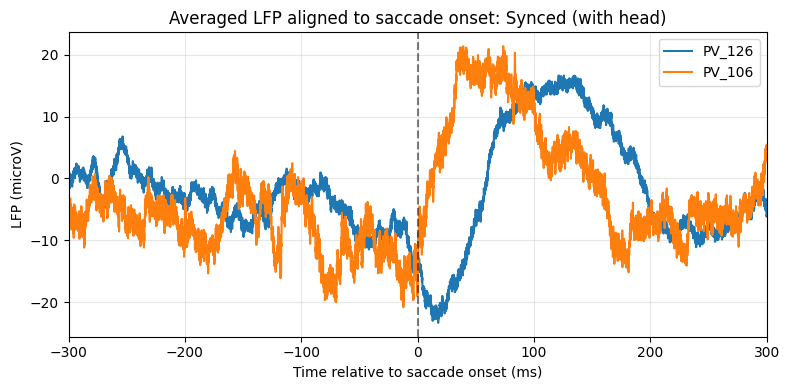

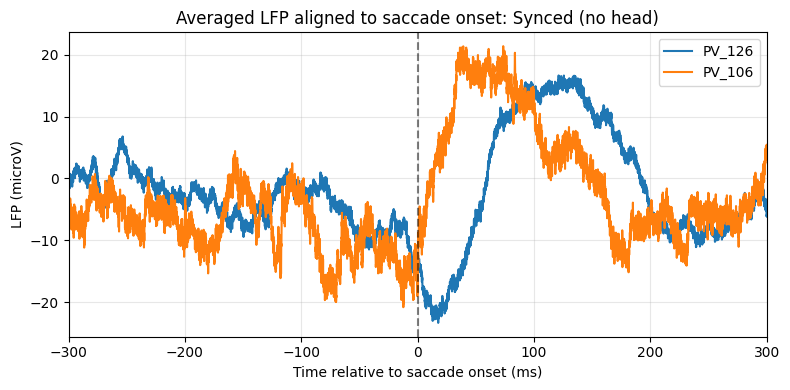

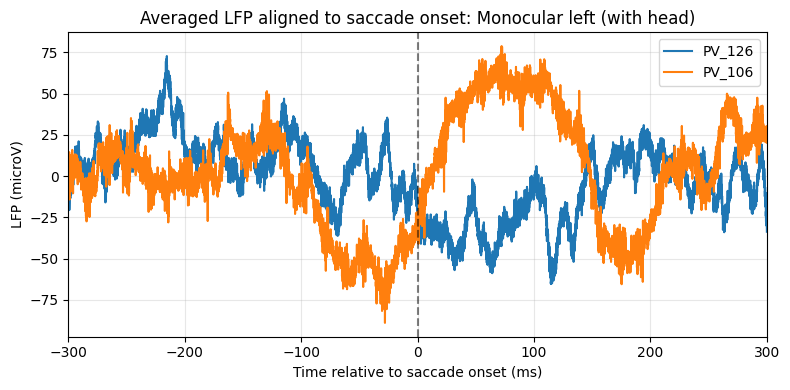

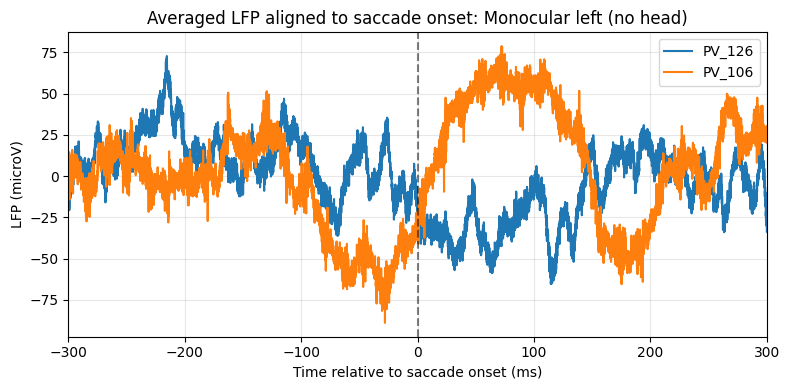

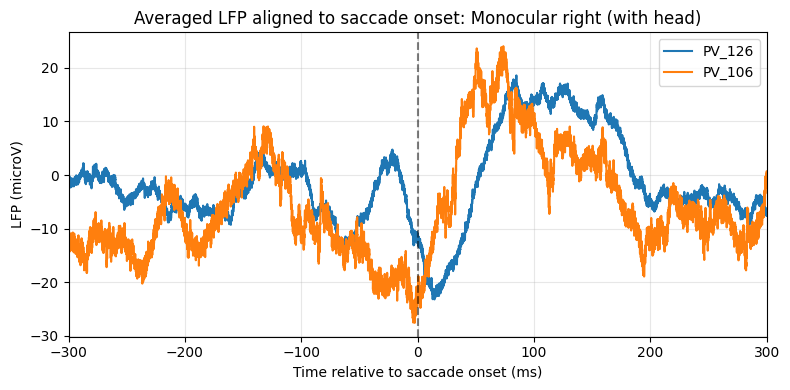

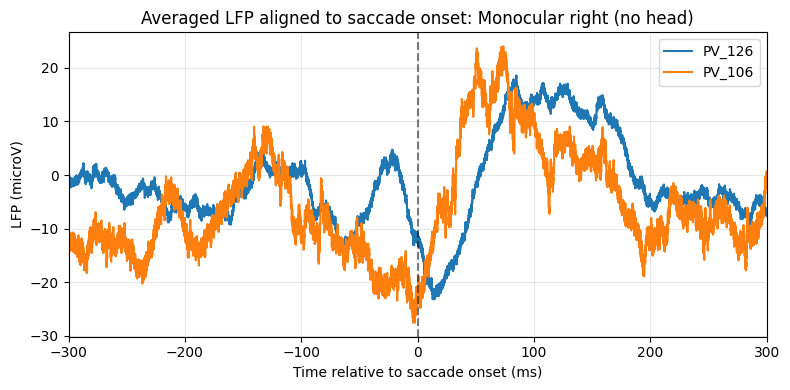

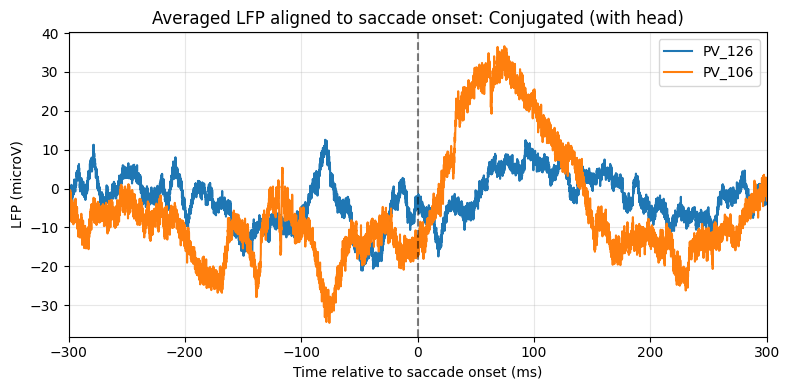

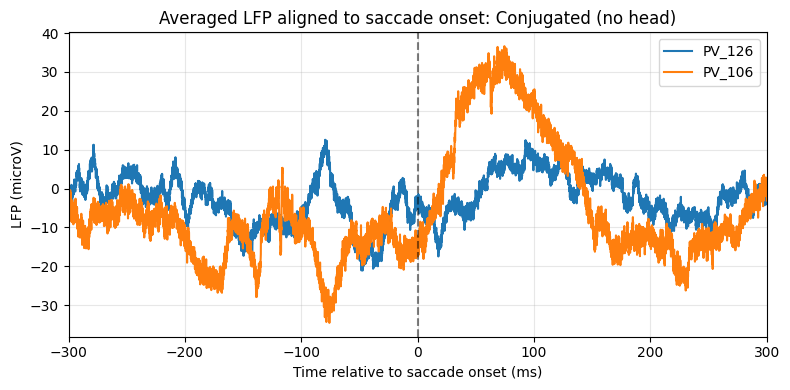

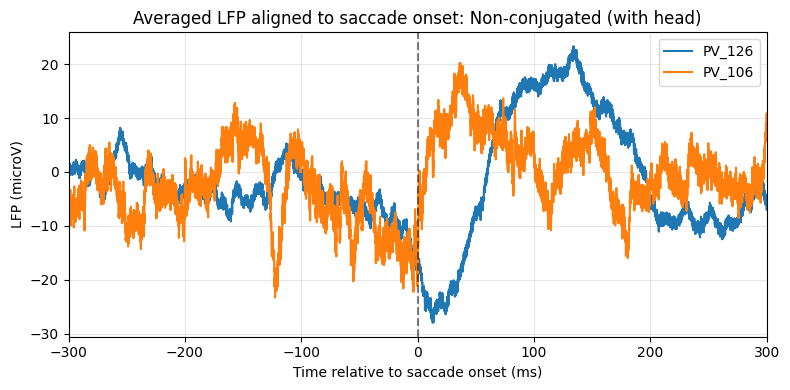

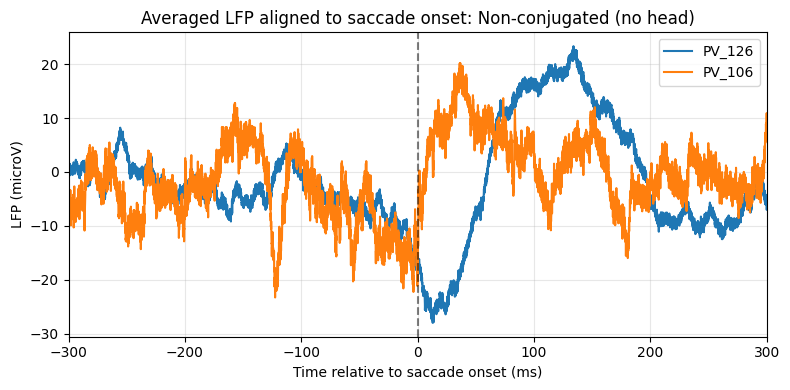

In [22]:
for name, _ in filtered_collections:
    mean_lfp_per_animal = mean_lfp_by_filter[name]
    if not mean_lfp_per_animal:
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    for animal, (t_rel, lfp) in mean_lfp_per_animal.items():
        ax.plot(t_rel, lfp, label=animal)
    ax.axvline(0, color="k", ls="--", alpha=0.5)
    ax.set_xlabel("Time relative to saccade onset (ms)")
    ax.set_ylabel("LFP (microV)")
    ax.set_title(f"Averaged LFP aligned to saccade onset: {name}")
    ax.legend()
    ax.set_xlim(-half_window_ms, half_window_ms)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()